# Lecture examples: 3D plotting and Calculus 3

**Tools:** NumPy and Matplotlib. **Suggested time:** 35–50 minutes, or select individual examples.

This notebook connects vectors, parametric curves, planes, functions of two variables, and tangent planes to Python plots. Examples use idealized geometry inspired by instrument paths and tissue surfaces; they are not anatomical or clinical models.

Run the setup cell first, then the examples in order. Every example includes the mathematical definition, working code, and a short question. No statistics or external datasets are needed.

## What kind of object are we plotting?

| Object | Mathematical description | Array structure | Matplotlib method |
|---|---|---|---|
| Curve or line | $\mathbf r(t)=(x(t),y(t),z(t))$ | Three matching 1D arrays | `ax.plot(x, y, z)` |
| Measured locations | $(x_i,y_i,z_i)$ | Three matching 1D arrays | `ax.scatter(x, y, z)` |
| Function surface | $z=f(x,y)$ | Matching 2D coordinate arrays | `ax.plot_surface(X, Y, Z)` |
| Parametric surface | $\mathbf r(u,v)$ | Matching 2D coordinate arrays | `ax.plot_surface(X, Y, Z)` |
| Surface grid | Either surface representation | Matching 2D coordinate arrays | `ax.plot_wireframe(X, Y, Z)` |

The key distinction is the number of independent parameters: a curve has one; a surface has two. A straight line still needs three coordinate arrays when it lives in 3D.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


def spatial_axes(title, figsize=(7, 5)):
    """Create a 3D axes for coordinates measured in millimeters."""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    ax.set(xlabel="x (mm)", ylabel="y (mm)", zlabel="z (mm)", title=title)
    ax.view_init(elev=25, azim=-55)
    return fig, ax


def equal_spatial_scale(ax, xlim, ylim, zlim):
    """Set box proportions from coordinate spans to avoid stretching geometry."""
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_zlim(zlim)
    ax.set_box_aspect([xlim[1] - xlim[0], ylim[1] - ylim[0], zlim[1] - zlim[0]])


## 1. A straight line segment: an idealized instrument path

A segment from $\mathbf p_0=(0,0,0)$ mm to $\mathbf p_1=(4,3,5)$ mm is

$$\mathbf r(t)=\mathbf p_0+t(\mathbf p_1-\mathbf p_0),\qquad 0\leq t\leq1.$$

Here $t$ is dimensionless. Restricting its interval gives a segment; an unrestricted parameter describes an infinite line. Python plots only a finite sampled interval.

**Teach:** matching 1D arrays, a 3D line, endpoint markers, and a direction vector. Labels distinguish endpoints without requiring color recognition.


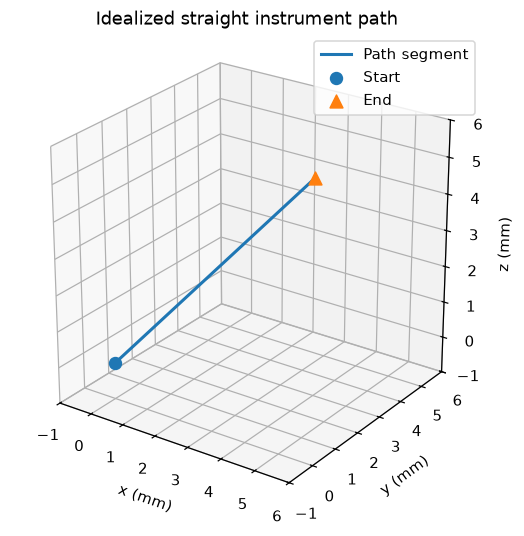

In [2]:
t = np.linspace(0, 1, 100)
p0 = np.array([0.0, 0.0, 0.0])
p1 = np.array([4.0, 3.0, 5.0])
direction = p1 - p0
x = p0[0] + t * direction[0]
y = p0[1] + t * direction[1]
z = p0[2] + t * direction[2]

fig, ax = spatial_axes("Idealized straight instrument path")
ax.plot(x, y, z, linewidth=2, label="Path segment")
ax.scatter(*p0, marker="o", s=60, label="Start")
ax.scatter(*p1, marker="^", s=70, label="End")
equal_spatial_scale(ax, (-1, 6), (-1, 6), (-1, 6))
ax.legend()
fig.tight_layout()
plt.show()


**Try:** Change the interval to $-0.5\leq t\leq1.5$. Which part of the line is still between the original endpoints? If an endpoint moves outside the visible area, update the axis limits too.

## 2. A parametric curve: a helical path

An idealized helical scan path is

$$x(\theta)=R\cos\theta,\quad y(\theta)=R\sin\theta,\quad z(\theta)=\frac{p\theta}{2\pi}.$$

$R=2$ mm is the radius and $p=1.5$ mm per revolution is the pitch. The angle runs from $0$ to $6\pi$ radians, giving three revolutions. This is a geometric path, not a model of blood flow.

**Teach:** vectorized trigonometric functions, radians, and three coordinates depending on the same parameter. The height is 4.5 mm, not the arc length of the curve.


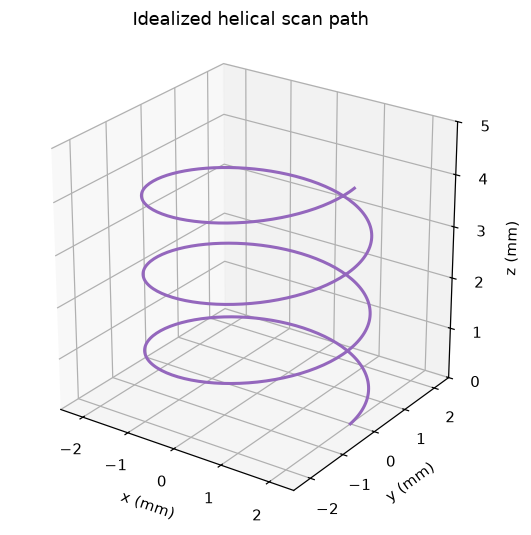

In [3]:
theta = np.linspace(0, 6 * np.pi, 500)
radius_mm = 2.0
pitch_mm = 1.5
helix_x = radius_mm * np.cos(theta)
helix_y = radius_mm * np.sin(theta)
helix_z = pitch_mm * theta / (2 * np.pi)

fig, ax = spatial_axes("Idealized helical scan path")
ax.plot(helix_x, helix_y, helix_z, color="tab:purple", linewidth=2)
equal_spatial_scale(ax, (-2.5, 2.5), (-2.5, 2.5), (0, 5))
fig.tight_layout()
plt.show()


**Try:** Double the pitch while keeping the angle interval fixed. Predict the number of revolutions and the final height before running the code.

## 3. A plane and its normal vector

Consider the plane

$$z=0.5x+0.25y+2,$$

where all coordinates are in mm, the slopes are dimensionless, and the intercept is 2 mm. In implicit form, $-0.5x-0.25y+z-2=0$, so a normal direction is $\mathbf n=(-0.5,-0.25,1)$.

A plane has two independent coordinates. `np.meshgrid(x_values, y_values)` generates arrays containing every x–y combination. With 21 x values and 17 y values, both coordinate arrays have shape `(17, 21)`: rows follow y, columns follow x. Evaluating the plane equation gives a Z array of the same shape.

**Teach:** why two 1D arrays alone are not a surface grid, `plot_surface`, and `quiver` for a vector. The arrow length below is chosen for display; it is not a measured quantity. Only a finite rectangular patch of the infinite plane is shown.


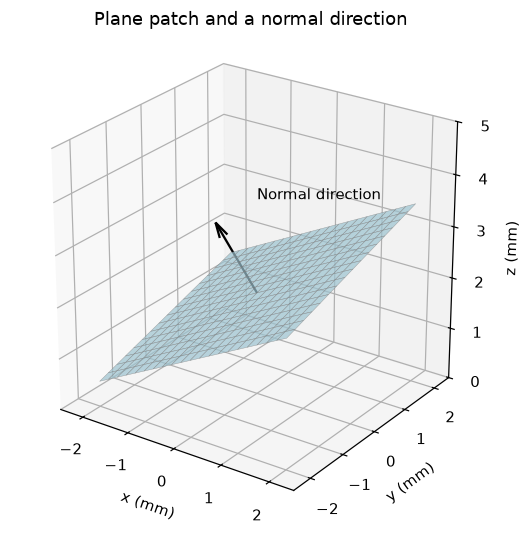

X, Y, and Z shapes: (17, 21) (17, 21) (17, 21)


In [4]:
x_values = np.linspace(-2, 2, 21)
y_values = np.linspace(-2, 2, 17)
X, Y = np.meshgrid(x_values, y_values)
Z_plane = 0.5 * X + 0.25 * Y + 2
print("X, Y, and Z shapes:", X.shape, Y.shape, Z_plane.shape)

fig, ax = spatial_axes("Plane patch and a normal direction")
ax.plot_surface(X, Y, Z_plane, color="lightblue", alpha=0.7,
                edgecolor="gray", linewidth=0.3)
normal = np.array([-0.5, -0.25, 1.0])
normal = normal / np.linalg.norm(normal)
ax.quiver(0, 0, 2, *normal, length=1.5, color="black", arrow_length_ratio=0.2)
ax.text(0, 0, 3.8, "Normal direction")
equal_spatial_scale(ax, (-2.5, 2.5), (-2.5, 2.5), (0, 5))
fig.tight_layout()
plt.show()


**Try:** Set both slopes to zero. What happens to the plane and its normal? Remember to update the normal vector when changing the equation.

**Calculus connection:** The vectors $(1,0,0.5)$ and $(0,1,0.25)$ lie along the plane. Their dot products with $\mathbf n$ are zero.

## 4. A curved surface and its contour map

Model an idealized raised surface as

$$f(x,y)=H\exp\left[-\frac{x^2+y^2}{2s^2}\right],$$

with height $H=3$ mm and width parameter $s=1.5$ mm. Because x, y, and s use the same units, the exponential's argument is dimensionless.

This is a function of two variables: every x–y pair has exactly one height. Compare the 3D surface with the 2D contour map of the **same** function. A contour connects locations with the same height.

**Teach:** a colormap and colorbar, level curves, and why a top-down view can make quantitative reading easier than perspective. Here color and vertical position encode the same quantity.


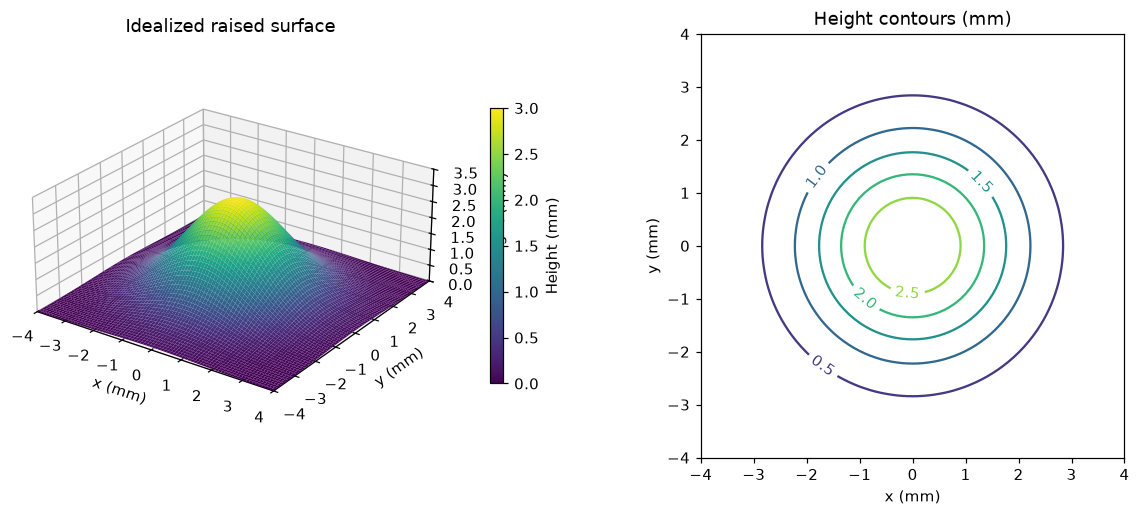

In [5]:
surface_x = np.linspace(-4, 4, 81)
surface_y = np.linspace(-4, 4, 81)
SX, SY = np.meshgrid(surface_x, surface_y)
height_mm = 3.0
width_mm = 1.5
SZ = height_mm * np.exp(-(SX**2 + SY**2) / (2 * width_mm**2))

fig = plt.figure(figsize=(11, 4.8))
ax3d = fig.add_subplot(121, projection="3d")
surface = ax3d.plot_surface(SX, SY, SZ, cmap="viridis", vmin=0, vmax=3,
                            rcount=81, ccount=81)
ax3d.set(xlabel="x (mm)", ylabel="y (mm)", zlabel="Height (mm)",
         title="Idealized raised surface")
ax3d.view_init(elev=25, azim=-55)
equal_spatial_scale(ax3d, (-4, 4), (-4, 4), (0, 3.5))
fig.colorbar(surface, ax=ax3d, shrink=0.65, pad=0.1, label="Height (mm)")

ax2d = fig.add_subplot(122)
contours = ax2d.contour(SX, SY, SZ, levels=[0.5, 1, 1.5, 2, 2.5],
                        cmap="viridis", vmin=0, vmax=3)
ax2d.clabel(contours, inline=True, fmt="%.1f")
ax2d.set(xlabel="x (mm)", ylabel="y (mm)", title="Height contours (mm)")
ax2d.set_aspect("equal")
fig.tight_layout()
plt.show()


**Try:** Increase s while keeping H fixed. Does the peak height change? What happens to the spacing of the contours?

## 5. A tangent plane: local linear approximation

For the previous function, a tangent plane at $(a,b)$ is

$$T(x,y)=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b).$$

The partial derivatives are

$$f_x=-\frac{x}{s^2}f(x,y),\qquad f_y=-\frac{y}{s^2}f(x,y).$$

Use $(a,b)=(1,0.5)$ mm. The derivatives have units mm/mm. The tangent plane approximates the surface near this point; it does not reproduce the whole surface.

**Teach:** partial derivatives as slopes, a wireframe overlay, the contact point, and a numerical check of local approximation. The black grid is a small patch of the tangent plane, not measured data.


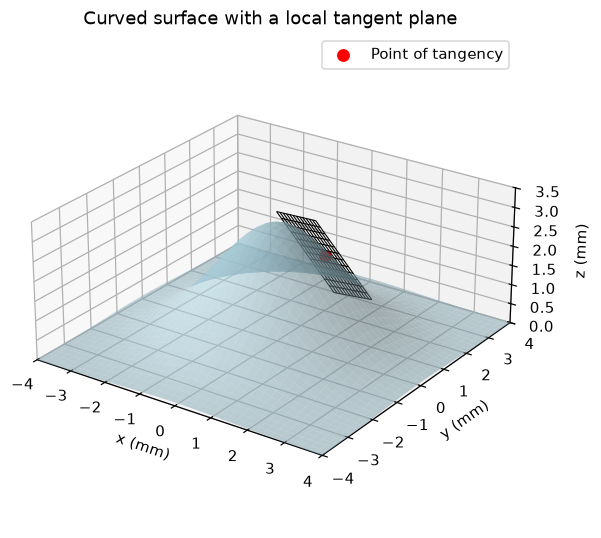

Height at contact: 2.272 mm
Partial slopes: fx = -1.010, fy = -0.505 mm/mm
dx = 0.1 mm: surface = 2.169 mm, plane = 2.171 mm, absolute error = 0.003 mm
dx = 0.5 mm: surface = 1.721 mm, plane = 1.767 mm, absolute error = 0.046 mm
dx = 1.0 mm: surface = 1.167 mm, plane = 1.262 mm, absolute error = 0.096 mm


In [6]:
a, b = 1.0, 0.5
f_ab = height_mm * np.exp(-(a**2 + b**2) / (2 * width_mm**2))
fx_ab = -(a / width_mm**2) * f_ab
fy_ab = -(b / width_mm**2) * f_ab
TX, TY = np.meshgrid(np.linspace(a - 0.8, a + 0.8, 13),
                     np.linspace(b - 0.8, b + 0.8, 13))
TZ = f_ab + fx_ab * (TX - a) + fy_ab * (TY - b)

fig, ax = spatial_axes("Curved surface with a local tangent plane")
ax.plot_surface(SX, SY, SZ, color="lightblue", alpha=0.55)
ax.plot_wireframe(TX, TY, TZ, color="black", linewidth=0.7)
ax.scatter(a, b, f_ab, color="red", s=55, label="Point of tangency")
equal_spatial_scale(ax, (-4, 4), (-4, 4), (0, 3.5))
ax.legend()
fig.tight_layout()
plt.show()

print(f"Height at contact: {f_ab:.3f} mm")
print(f"Partial slopes: fx = {fx_ab:.3f}, fy = {fy_ab:.3f} mm/mm")
for dx in [0.1, 0.5, 1.0]:
    exact = height_mm * np.exp(-((a + dx)**2 + b**2) / (2 * width_mm**2))
    approximate = f_ab + fx_ab * dx
    print(f"dx = {dx:.1f} mm: surface = {exact:.3f} mm, "
          f"plane = {approximate:.3f} mm, absolute error = {abs(exact - approximate):.3f} mm")


**Try:** Move the contact point to $(0,0)$. Predict both partial derivatives and the orientation of the tangent plane. Rerun the complete cell so all dependent values update.

## 6. Optional: a parametric surface that is not z = f(x,y)

A sphere is an idealized bead geometry. Its full surface cannot be represented by a single-valued height function because many x–y locations have both an upper and a lower z value. Use two angles instead:

$$x=R\sin\phi\cos\theta,\quad y=R\sin\phi\sin\theta,\quad z=R\cos\phi,$$

where $0\leq\theta\leq2\pi$ and $0\leq\phi\leq\pi$. Here $R=2$ mm, theta is the azimuthal angle, and phi is measured down from the positive z axis. Calculus textbooks vary in their angle notation, so always define it.

**Teach:** `meshgrid` can sample parameter space as well as physical x–y space. Both angles are in radians. The repeated seam and poles are expected in this parameterization.


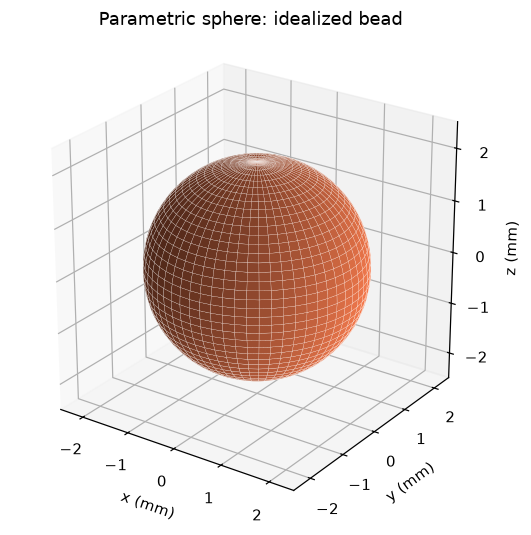

Maximum radius error (mm): 4.440892098500626e-16


In [7]:
azimuth = np.linspace(0, 2 * np.pi, 61)
polar = np.linspace(0, np.pi, 41)
THETA, PHI = np.meshgrid(azimuth, polar)
bead_radius_mm = 2.0
BX = bead_radius_mm * np.sin(PHI) * np.cos(THETA)
BY = bead_radius_mm * np.sin(PHI) * np.sin(THETA)
BZ = bead_radius_mm * np.cos(PHI)

fig, ax = spatial_axes("Parametric sphere: idealized bead")
ax.plot_surface(BX, BY, BZ, color="coral", rcount=41, ccount=61,
                edgecolor="white", linewidth=0.15)
equal_spatial_scale(ax, (-2.5, 2.5), (-2.5, 2.5), (-2.5, 2.5))
fig.tight_layout()
plt.show()
print("Maximum radius error (mm):",
      np.max(np.abs(np.sqrt(BX**2 + BY**2 + BZ**2) - bead_radius_mm)))


**Try:** Multiply BX by 1.5 to make an ellipsoid. Update the x limits and box proportions so the intended shape is displayed accurately.

## Practical 3D plotting choices

- **Camera:** `ax.view_init(elev=25, azim=-55)` changes the viewing direction, not the data. Try a second angle if features overlap. A standard notebook's static images do not rotate by dragging; interactive rotation depends on the notebook backend. All examples work as static figures.
- **Scale:** When all axes describe spatial coordinates with the same units, set box proportions to their numeric spans. A sphere should look spherical. With different axis units, such as position, time, and voltage, equal geometric scaling has no direct physical meaning.
- **Visibility:** Opaque surfaces can hide curves and points. Transparency helps, but overlapping 3D surfaces can still have rendering artifacts. Use a second view, contour map, or cross section to check an apparent intersection.
- **Resolution:** More samples make rendered curves and surfaces smoother; they do not add experimental evidence. `plot_surface` can downsample large arrays, so set `rcount` and `ccount` when needed, as in the surface example.
- **Labels:** Name all three axes and include units. If a colormap encodes a numerical value, explain it with a colorbar. A constant surface color is decorative and does not need a colorbar.
- **Export:** Add `fig.savefig("surface_example.png", dpi=200, bbox_inches="tight")` before `plt.show()` to save a report image. A saved image has a fixed camera angle.

## Short student challenge

Plot the saddle $z=(x^2-y^2)/L$ on $-2\leq x,y\leq2$ mm, using $L=2$ mm so z also has units of mm. Include a labeled colorbar and a contour map. Then overlay the x-axis cross section $(t,0,t^2/L)$ as a black curve on the 3D surface. Predict the shape of the y-axis cross section before plotting it.

**Explain:** Why is the cross section a curve even though it lies on a surface? How many independent parameters does each object require?


In [8]:
# Optional challenge: write your solution here.
